# Anxiety Model

## Import Library


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [3]:
df = pd.read_csv('data/Anxiety.csv')
df.head()

,1. Age,2. Gender,3. University,4. Department,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,Anxiety Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,2,2,3,2,2,2,2,15,Severe Anxiety
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,1,2,2,1,1,3,2,12,Moderate Anxiety
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,0,0,0,Minimal Anxiety
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,2,1,1,1,2,1,2,10,Moderate Anxiety
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,0,3,3,1,1,3,14,Moderate Anxiety


## Preprocessing Data

In [6]:
# Pemisahan fitur dan target
X = df.drop(['Anxiety Value', 'Anxiety Label'], axis=1)
y = df['Anxiety Label']

# Mengelompokkan fitur numerik dan kategorikal
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Fitur Numerik:", list(numeric_features))
print("Fitur Kategorikal:", list(categorical_features))

Fitur Numerik: ['1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?']
Fitur Kategorikal: ['1. Age', '2. Gender', '3. University', '4. Department', '5. Academic Year', '6. Current CGPA', '7. Did you receive a waiver or scholarship at your university?']


In [7]:
# Membuat preprocessor untuk fitur numerik dan kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ], remainder='passthrough'
)

In [9]:
# Pipeline untuk model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'))
])

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latih: 1622
Jumlah data uji: 406


## Hyperparameter Tuning

In [11]:
# Grid Search untuk hyperparameter tuning
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'] 
}

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid,
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)

print("Memulai Grid Search...")
grid_search.fit(X_train, y_train)

print("parameter terbaik:", grid_search.best_params_)

Memulai Grid Search...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
parameter terbaik: {'classifier__C': 100, 'classifier__penalty': 'l2'}


## Evaluasi Model

In [12]:
# Mengambil model terbaik dari Grid Search
best_model = grid_search.best_estimator_

# Evaluasi model terbaik pada data uji
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi pada data uji:", f"{accuracy * 100:.2f}%", "\n")
print("Classification Report:", "\n", classification_report(y_test, y_pred))

Akurasi pada data uji: 99.51% 

Classification Report: 
                   precision    recall  f1-score   support

    Mild Anxiety       1.00      0.98      0.99       101
 Minimal Anxiety       0.94      1.00      0.97        32
Moderate Anxiety       1.00      1.00      1.00       124
  Severe Anxiety       1.00      1.00      1.00       149

        accuracy                           1.00       406
       macro avg       0.99      1.00      0.99       406
    weighted avg       1.00      1.00      1.00       406



## Visualisasi Confusion Matrix

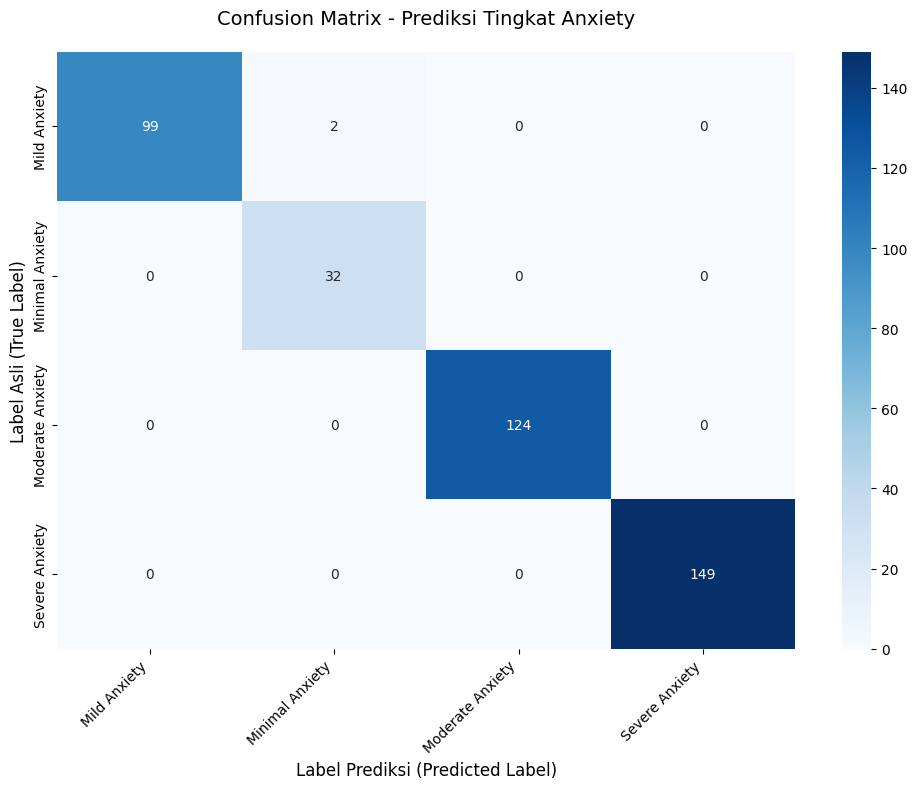

In [13]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix - Prediksi Tingkat Anxiety', pad=20, fontsize=14)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Saved Model

In [15]:
# Saved model
import joblib
import os

path = os.path.join('saved_models', 'anxiety_model.pkl')
joblib.dump(best_model, path)
print(f"Model terbaik telah disimpan di: {path}")

Model terbaik telah disimpan di: saved_models\anxiety_model.pkl


In [16]:
print(df.columns.tolist())

['1. Age', '2. Gender', '3. University', '4. Department', '5. Academic Year', '6. Current CGPA', '7. Did you receive a waiver or scholarship at your university?', '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?', 'Anxiety Value', 'Anxiety Label']
